# 第 1 章　张量的物理与几何基础：计算伴侣

本 Notebook 是《张量分析》第 1 章的配套电子资源。它不重复纸质教材的完整理论推导，而是围绕本章中最适合计算实验的内容建立“**公式—代码—图像—自检**”闭环。

本书统一采用“输出—输入”约定：

$$
t_i^{(\mathbf n)}=\sigma_{ij}n_j,
\qquad
\mathbf t^{(\mathbf n)}=\boldsymbol\sigma\mathbf n.
$$

因此，应力矩阵的第 $j$ 列表示法向为 $\mathbf e_j$ 的坐标面上的面力分量。

> **代码约定**  
> 为与教材保持一致，凡涉及指标求和、张量缩并和分量运算，优先使用显式 `for` 循环；不使用 `@` 和 `np.einsum`。NumPy 主要用于数组存储、线性代数、随机采样和数值工具。

## 学习目标与使用方法

完成本 Notebook 后，应能够：

1. 用数值计算验证矢量分量随基底改变而变化、矢量模长保持不变；
2. 用量级计算理解柯西引理和四面体推导中 $O(h^3)$ 体积项相对于 $O(h^2)$ 面积项为何消失；
3. 计算任意截面上的面力、法向应力和剪应力；
4. 验证 $\mathbf n$ 与 $-\mathbf n$ 对应的定向截面关系；
5. 通过纯剪切状态生成完整的莫尔圆参数轨迹；
6. 用球面网格搜索最大剪应力截面；
7. 用随机方向测试本章公式；
8. 用六个方向的法向应力测量重构一个对称应力张量。

建议按顺序运行全部单元格，然后修改应力张量、截面法向和网格分辨率，观察结果如何变化。

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=6, suppress=True)
rng = np.random.default_rng(20260823)

print("NumPy version:", np.__version__)

NumPy version: 2.3.5


## 1. 矢量的坐标投影：对应诊断式工程例题 1-1

地面坐标系中

$$
\mathbf V=20\mathbf E_1+15\mathbf E_2\quad(\mathrm{m/s}),
$$

机体坐标系相对地面坐标系逆时针旋转 $30^\circ$。下面直接用点积计算新基底下的分量，并验证矢量模长不变。

In [2]:
V = np.array([20.0, 15.0])
alpha = np.radians(30.0)

e1 = np.array([np.cos(alpha), np.sin(alpha)])
e2 = np.array([-np.sin(alpha), np.cos(alpha)])

def dot_loop(a, b):
    value = 0.0
    for i in range(len(a)):
        value += a[i] * b[i]
    return value

V1_prime = dot_loop(V, e1)
V2_prime = dot_loop(V, e2)

norm_old = np.linalg.norm(V)
norm_new = np.sqrt(V1_prime**2 + V2_prime**2)

print(f"V'_1 = {V1_prime:.6f} m/s")
print(f"V'_2 = {V2_prime:.6f} m/s")
print(f"|V| before = {norm_old:.6f} m/s")
print(f"|V| after  = {norm_new:.6f} m/s")

assert np.isclose(norm_old, norm_new)

V'_1 = 24.820508 m/s
V'_2 = 2.990381 m/s
|V| before = 25.000000 m/s
|V| after  = 25.000000 m/s


**观察：** 坐标分量改变，但模长保持不变。可将 `alpha` 改为其他角度，验证这一结论。

## 2. 柯西四面体的量级：为什么体积项在局部极限中消失？

若特征尺寸为 $h$，则

$$
\Delta S=O(h^2),\qquad
\Delta V=O(h^3),
$$

因此

$$
\frac{\Delta V}{\Delta S}=O(h).
$$

下面用一组逐渐减小的 $h$ 直接观察这一缩放关系。这里展示的是**量级关系**，不是某个具体连续体的几何精确系数。

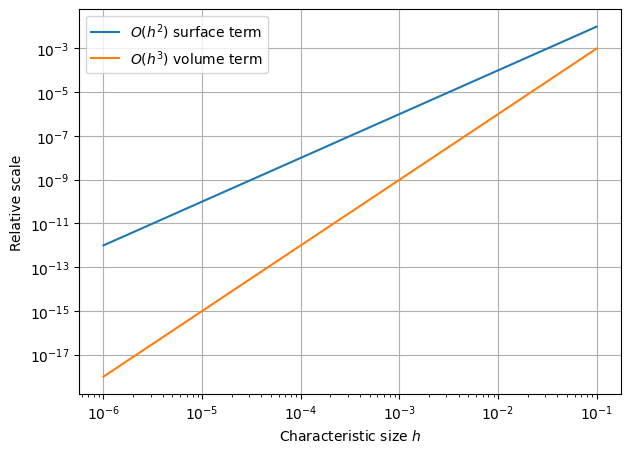

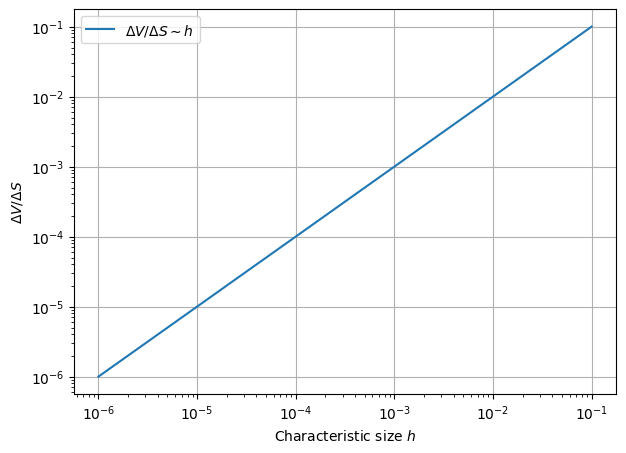

当 h 缩小 10 倍时，ΔV/ΔS 也缩小约 10 倍。


In [3]:
h = np.logspace(-1, -6, 100)
area_scale = h**2
volume_scale = h**3
ratio = volume_scale / area_scale

plt.figure(figsize=(7, 5))
plt.loglog(h, area_scale, label=r"$O(h^2)$ surface term")
plt.loglog(h, volume_scale, label=r"$O(h^3)$ volume term")
plt.xlabel(r"Characteristic size $h$")
plt.ylabel("Relative scale")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(7, 5))
plt.loglog(h, ratio, label=r"$\Delta V/\Delta S \sim h$")
plt.xlabel(r"Characteristic size $h$")
plt.ylabel(r"$\Delta V/\Delta S$")
plt.grid(True)
plt.legend()
plt.show()

print("当 h 缩小 10 倍时，ΔV/ΔS 也缩小约 10 倍。")

这说明在 $\rho$、$\mathbf b$ 与 $\mathbf a$ 有界时，将动量平衡除以面积尺度后，体积力项和惯性项都含有一个 $O(h)$ 因子。它们在 $h\to0$ 的局部极限中消失，但并不意味着体积力和惯性力不会影响真实应力场。

## 3. 单向拉伸状态的斜截面应力：数字赋能 01-A

单向拉伸状态中

$$
\boldsymbol\sigma=
\begin{bmatrix}
\sigma_0&0\\
0&0
\end{bmatrix}.
$$

令截面法向

$$
\mathbf n=(\cos\theta,\sin\theta)^{\mathsf T},
$$

截面切向单位矢量取为

$$
\mathbf s=(-\sin\theta,\cos\theta)^{\mathsf T}.
$$

下面从面力矢量出发计算 $\sigma_n$ 与带符号切向应力 $\tau_s$。

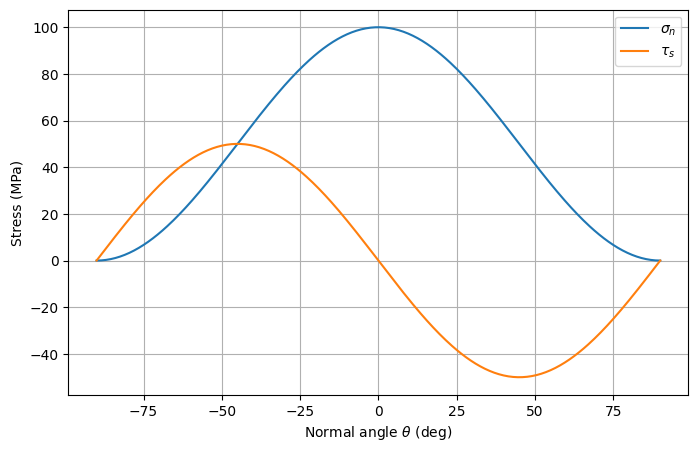

theta = 0 deg: sigma_n = 100.000 MPa, tau = 0.000 MPa
theta = 45 deg: sigma_n = 50.000 MPa, tau = 50.000 MPa
maximum |tau| = 50.000 MPa


In [4]:
sigma_0 = 100.0  # MPa
theta_deg = np.linspace(-90.0, 90.0, 361)
theta = np.radians(theta_deg)

n = np.column_stack((np.cos(theta), np.sin(theta)))
s = np.column_stack((-np.sin(theta), np.cos(theta)))

traction = np.column_stack(
    (sigma_0 * np.cos(theta), np.zeros_like(theta))
)

n_sections = theta.size
sigma_n = np.zeros(n_sections)
tau_signed = np.zeros(n_sections)

for p in range(n_sections):
    for i in range(2):
        sigma_n[p] += traction[p, i] * n[p, i]
        tau_signed[p] += traction[p, i] * s[p, i]

tau_magnitude = np.abs(tau_signed)

plt.figure(figsize=(8, 5))
plt.plot(theta_deg, sigma_n, label=r"$\sigma_n$")
plt.plot(theta_deg, tau_signed, label=r"$\tau_s$")
plt.xlabel(r"Normal angle $\theta$ (deg)")
plt.ylabel("Stress (MPa)")
plt.grid(True)
plt.legend()
plt.show()

idx0 = np.argmin(np.abs(theta_deg - 0.0))
idx45 = np.argmin(np.abs(theta_deg - 45.0))

print(f"theta = 0 deg: sigma_n = {sigma_n[idx0]:.3f} MPa, tau = {tau_magnitude[idx0]:.3f} MPa")
print(f"theta = 45 deg: sigma_n = {sigma_n[idx45]:.3f} MPa, tau = {tau_magnitude[idx45]:.3f} MPa")
print(f"maximum |tau| = {tau_magnitude.max():.3f} MPa")

assert np.isclose(sigma_n[idx0], sigma_0)
assert np.isclose(tau_magnitude[idx0], 0.0, atol=1e-12)
assert np.isclose(tau_magnitude.max(), sigma_0 / 2.0, atol=1e-12)

## 4. 通用截面应力分析：数字赋能 01-B

对任意三维应力张量与截面法向，依次计算

$$
t_i=\sigma_{ij}n_j,
$$

$$
\sigma_n=n_it_i,
$$

$$
\boldsymbol\tau^{(\mathbf n)}
=\mathbf t-\sigma_n\mathbf n.
$$

函数内部显式写出指标缩并。

In [5]:
def analyze_traction(sigma_matrix, normal_vector):
    sigma = np.asarray(sigma_matrix, dtype=float)
    n = np.asarray(normal_vector, dtype=float)

    if sigma.shape != (3, 3):
        raise ValueError("sigma_matrix 必须是 3×3 数组。")
    if n.shape != (3,):
        raise ValueError("normal_vector 必须含有 3 个分量。")

    norm_n = np.linalg.norm(n)
    if np.isclose(norm_n, 0.0):
        raise ValueError("法向量不能是零向量。")

    n = n / norm_n

    # t_i = sigma_ij n_j
    traction = np.zeros(3)
    for i in range(3):
        for j in range(3):
            traction[i] += sigma[i, j] * n[j]

    # sigma_n = n_i t_i
    normal_stress = 0.0
    for i in range(3):
        normal_stress += n[i] * traction[i]

    shear_vector = traction - normal_stress * n
    shear_magnitude = np.linalg.norm(shear_vector)

    return traction, normal_stress, shear_vector, shear_magnitude


sigma = np.array([
    [120.0,  40.0,  0.0],
    [ 40.0, -30.0,  0.0],
    [  0.0,   0.0, 10.0],
])

normal = np.array([0.5, np.sqrt(3.0) / 2.0, 0.0])

t, sigma_n_value, tau_vec, tau_mag = analyze_traction(sigma, normal)

print("t(n) =", np.round(t, 3), "MPa")
print("sigma_n =", round(sigma_n_value, 3), "MPa")
print("tau(n) =", np.round(tau_vec, 3), "MPa")
print("|tau| =", round(tau_mag, 3), "MPa")

t(n) = [94.641 -5.981  0.   ] MPa
sigma_n = 42.141 MPa
tau(n) = [ 73.571 -42.476   0.   ] MPa
|tau| = 84.952 MPa


### 基准截面自检：矩阵第 $j$ 列就是 $\mathbf t^{(\mathbf e_j)}$

这是本书“第一指标 = 输出分量、第二指标 = 输入方向”规则最直接的数值检查。

In [6]:
for j in range(3):
    basis_normal = np.zeros(3)
    basis_normal[j] = 1.0

    traction_j, *_ = analyze_traction(sigma, basis_normal)

    print(
        f"n = e_{j+1}: traction = {traction_j}; "
        f"column {j+1} = {sigma[:, j]}"
    )
    assert np.allclose(traction_j, sigma[:, j])

n = e_1: traction = [120.  40.   0.]; column 1 = [120.  40.   0.]
n = e_2: traction = [ 40. -30.   0.]; column 2 = [ 40. -30.   0.]
n = e_3: traction = [ 0.  0. 10.]; column 3 = [ 0.  0. 10.]


## 5. 定向截面反转：验证 $\mathbf n\leftrightarrow-\mathbf n$

根据柯西公式，

$$
\mathbf t^{(-\mathbf n)}=-\mathbf t^{(\mathbf n)}.
$$

同时，

$$
\sigma_{-\mathbf n}=\sigma_{\mathbf n},
\qquad
\boldsymbol\tau^{(-\mathbf n)}
=-\boldsymbol\tau^{(\mathbf n)},
\qquad
\tau_{-\mathbf n}=\tau_{\mathbf n}.
$$

下面不预先假设应力张量对称，直接做数值验证。

In [7]:
sigma_nonsym = np.array([
    [120.0,  20.0, -10.0],
    [ 35.0, -30.0,  15.0],
    [  5.0, -25.0,  40.0],
])

n_test = np.array([2.0, -1.0, 3.0])

t_plus, sn_plus, tau_plus, taum_plus = analyze_traction(sigma_nonsym, n_test)
t_minus, sn_minus, tau_minus, taum_minus = analyze_traction(sigma_nonsym, -n_test)

print("||t(-n) + t(n)|| =", np.linalg.norm(t_minus + t_plus))
print("|sigma_-n - sigma_n| =", abs(sn_minus - sn_plus))
print("||tau(-n) + tau(n)|| =", np.linalg.norm(tau_minus + tau_plus))
print("||tau_-n| - |tau_n|| =", abs(taum_minus - taum_plus))

assert np.allclose(t_minus, -t_plus)
assert np.isclose(sn_minus, sn_plus)
assert np.allclose(tau_minus, -tau_plus)
assert np.isclose(taum_minus, taum_plus)

||t(-n) + t(n)|| = 0.0
|sigma_-n - sigma_n| = 0.0
||tau(-n) + tau(n)|| = 0.0
||tau_-n| - |tau_n|| = 0.0


## 6. 纯剪切状态与完整莫尔圆轨迹：对应习题 1.10

给定

$$
\boldsymbol\sigma=
\begin{bmatrix}
0&100\\
100&0
\end{bmatrix}\ \mathrm{MPa}.
$$

对

$$
\mathbf n=(\cos\theta,\sin\theta)^{\mathsf T},
$$

计算法向应力 $\sigma_n$ 和沿

$$
\mathbf s=(-\sin\theta,\cos\theta)^{\mathsf T}
$$

的带符号切向应力 $\tau_s$。使用带符号的 $\tau_s$ 才能保留截面切向方向信息。

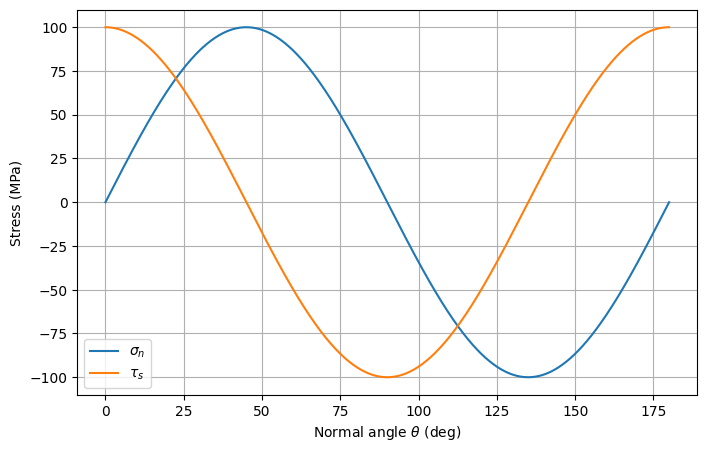

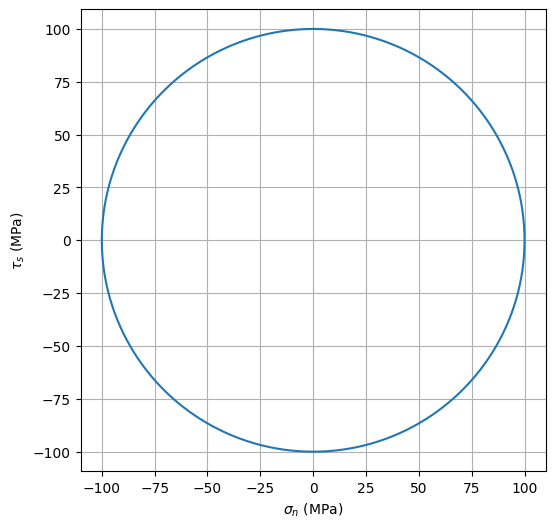

max circle identity error = 5.4569682106375694e-12


In [8]:
sigma2 = np.array([
    [0.0, 100.0],
    [100.0, 0.0],
])

theta_deg_2 = np.linspace(0.0, 180.0, 721)
theta_2 = np.radians(theta_deg_2)

sigma_normal_2 = np.zeros(theta_2.size)
tau_signed_2 = np.zeros(theta_2.size)

for p, angle in enumerate(theta_2):
    normal2 = np.array([np.cos(angle), np.sin(angle)])
    tangent2 = np.array([-np.sin(angle), np.cos(angle)])

    traction2 = np.zeros(2)
    for i in range(2):
        for j in range(2):
            traction2[i] += sigma2[i, j] * normal2[j]

    for i in range(2):
        sigma_normal_2[p] += normal2[i] * traction2[i]
        tau_signed_2[p] += tangent2[i] * traction2[i]

plt.figure(figsize=(8, 5))
plt.plot(theta_deg_2, sigma_normal_2, label=r"$\sigma_n$")
plt.plot(theta_deg_2, tau_signed_2, label=r"$\tau_s$")
plt.xlabel(r"Normal angle $\theta$ (deg)")
plt.ylabel("Stress (MPa)")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(6, 6))
plt.plot(sigma_normal_2, tau_signed_2)
plt.xlabel(r"$\sigma_n$ (MPa)")
plt.ylabel(r"$\tau_s$ (MPa)")
plt.axis("equal")
plt.grid(True)
plt.show()

circle_error = np.max(
    np.abs(sigma_normal_2**2 + tau_signed_2**2 - 100.0**2)
)
print("max circle identity error =", circle_error)

assert circle_error < 1e-8

若把纵轴改为 $|\tau_s|$，轨迹会被折叠到上半平面，从而丢失切向方向的符号信息。

## 7. 球面网格搜索最大剪应力截面：对应习题 1.11

给定

$$
\boldsymbol\sigma=
\begin{bmatrix}
350&-80&45\\
-80&120&60\\
45&60&-50
\end{bmatrix}\ \mathrm{MPa},
$$

在球面单位法向上搜索

$$
\tau_n=
\left\|
\boldsymbol\sigma\mathbf n
-
(\mathbf n\cdot\boldsymbol\sigma\mathbf n)\mathbf n
\right\|.
$$

这里采用 $181\times121$ 的方向网格，超过题目要求的 $100\times100$。

grid maximum tau = 228.287162 MPa
one normal at maximum = [-0.792278 -0.041292  0.608761]
angles: theta = 182.983 deg, phi = 52.5 deg
tau(-n) = 228.287162 MPa


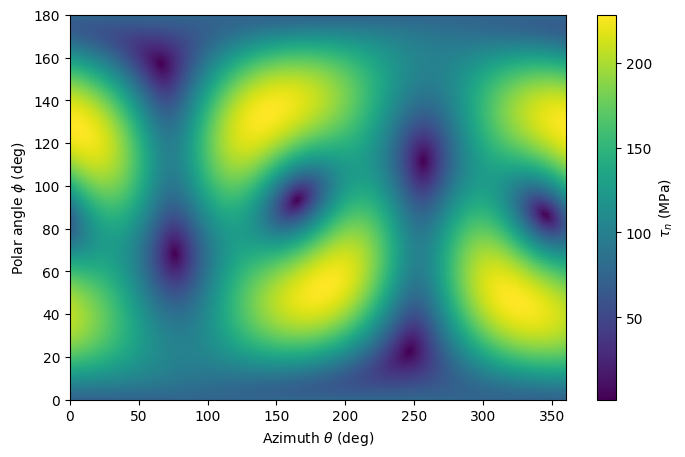

In [9]:
sigma_search = np.array([
    [350.0, -80.0,  45.0],
    [-80.0, 120.0,  60.0],
    [ 45.0,  60.0, -50.0],
])

theta_grid = np.linspace(0.0, 2.0 * np.pi, 181, endpoint=False)
phi_grid = np.linspace(0.0, np.pi, 121)

tau_grid = np.zeros((phi_grid.size, theta_grid.size))

tau_max = -np.inf
n_at_max = None
theta_at_max = None
phi_at_max = None

for q, phi in enumerate(phi_grid):
    for p, theta in enumerate(theta_grid):
        n_dir = np.array([
            np.sin(phi) * np.cos(theta),
            np.sin(phi) * np.sin(theta),
            np.cos(phi),
        ])

        _, _, _, tau_value = analyze_traction(sigma_search, n_dir)
        tau_grid[q, p] = tau_value

        if tau_value > tau_max:
            tau_max = tau_value
            n_at_max = n_dir.copy()
            theta_at_max = theta
            phi_at_max = phi

print(f"grid maximum tau = {tau_max:.6f} MPa")
print("one normal at maximum =", np.round(n_at_max, 6))
print(
    "angles: theta =",
    round(np.degrees(theta_at_max), 3),
    "deg, phi =",
    round(np.degrees(phi_at_max), 3),
    "deg"
)

# 验证相反法向对应同一几何平面，剪应力大小相同
_, _, _, tau_opposite = analyze_traction(sigma_search, -n_at_max)
print("tau(-n) =", round(tau_opposite, 6), "MPa")
assert np.isclose(tau_max, tau_opposite)

plt.figure(figsize=(8, 5))
plt.imshow(
    tau_grid,
    origin="lower",
    aspect="auto",
    extent=[0.0, 360.0, 0.0, 180.0],
)
plt.xlabel(r"Azimuth $\theta$ (deg)")
plt.ylabel(r"Polar angle $\phi$ (deg)")
plt.colorbar(label=r"$\tau_n$ (MPa)")
plt.show()

> **注意**  
> 网格搜索得到的是离散近似最大值。提高球面分辨率会得到更精细的方向估计。第三章学习主应力后，可以从谱性质进一步解释最大剪应力。

## 8. 随机方向批量验证：对应习题 1.12

下面随机生成 20 个单位法向，同时检查：

- $\boldsymbol\tau^{(p)}\cdot\mathbf n^{(p)}\approx0$；
- $\mathbf t^{(-\mathbf n)}=-\mathbf t^{(\mathbf n)}$；
- $\sigma_{-\mathbf n}=\sigma_{\mathbf n}$；
- $\boldsymbol\tau^{(-\mathbf n)}=-\boldsymbol\tau^{(\mathbf n)}$；
- $\tau_{-\mathbf n}=\tau_{\mathbf n}$。

In [10]:
sigma_batch = np.array([
    [180.0,  30.0, -20.0],
    [ 30.0,  60.0,  25.0],
    [-20.0,  25.0, -40.0],
])

n_samples = 20
normals = rng.normal(size=(n_samples, 3))

for p in range(n_samples):
    normals[p] = normals[p] / np.linalg.norm(normals[p])

max_tau_dot_n = 0.0
max_traction_reversal_error = 0.0
max_normal_stress_error = 0.0
max_shear_reversal_error = 0.0
max_shear_magnitude_error = 0.0

for p in range(n_samples):
    n_dir = normals[p]

    t1, sn1, tau1, tm1 = analyze_traction(sigma_batch, n_dir)
    t2, sn2, tau2, tm2 = analyze_traction(sigma_batch, -n_dir)

    tau_dot_n = 0.0
    for i in range(3):
        tau_dot_n += tau1[i] * n_dir[i]

    max_tau_dot_n = max(max_tau_dot_n, abs(tau_dot_n))
    max_traction_reversal_error = max(
        max_traction_reversal_error, np.linalg.norm(t2 + t1)
    )
    max_normal_stress_error = max(
        max_normal_stress_error, abs(sn2 - sn1)
    )
    max_shear_reversal_error = max(
        max_shear_reversal_error, np.linalg.norm(tau2 + tau1)
    )
    max_shear_magnitude_error = max(
        max_shear_magnitude_error, abs(tm2 - tm1)
    )

print("max |tau·n| =", max_tau_dot_n)
print("max traction reversal error =", max_traction_reversal_error)
print("max normal-stress invariance error =", max_normal_stress_error)
print("max shear-vector reversal error =", max_shear_reversal_error)
print("max shear-magnitude invariance error =", max_shear_magnitude_error)

assert max_tau_dot_n < 1e-10
assert max_traction_reversal_error < 1e-10
assert max_normal_stress_error < 1e-10
assert max_shear_reversal_error < 1e-10
assert max_shear_magnitude_error < 1e-10

max |tau·n| = 6.394884621840902e-14
max traction reversal error = 0.0
max normal-stress invariance error = 0.0
max shear-vector reversal error = 0.0
max shear-magnitude invariance error = 0.0


## 9. 由六个方向的法向应力重构对称应力张量：对应习题 1.13

经典柯西连续体中若

$$
\boldsymbol\sigma=\boldsymbol\sigma^{\mathsf T},
$$

则三维应力张量只有六个独立分量。记未知量为

$$
\mathbf x=
(\sigma_{11},\sigma_{22},\sigma_{33},
\sigma_{12},\sigma_{13},\sigma_{23})^{\mathsf T}.
$$

对给定单位法向 $\mathbf n=(n_1,n_2,n_3)^{\mathsf T}$，

$$
\sigma_n
=
\sigma_{11}n_1^2+\sigma_{22}n_2^2+\sigma_{33}n_3^2
+2\sigma_{12}n_1n_2+2\sigma_{13}n_1n_3+2\sigma_{23}n_2n_3.
$$

因此，每个方向测量给出一个关于六个未知量的线性方程。

In [11]:
sigma_true = np.array([
    [180.0,  30.0, -20.0],
    [ 30.0,  60.0,  25.0],
    [-20.0,  25.0, -40.0],
])

directions = np.array([
    [1.0, 0.0, 0.0],
    [0.0, 1.0, 0.0],
    [0.0, 0.0, 1.0],
    [1.0, 1.0, 0.0],
    [1.0, 0.0, 1.0],
    [0.0, 1.0, 1.0],
], dtype=float)

for p in range(directions.shape[0]):
    directions[p] /= np.linalg.norm(directions[p])

A = np.zeros((6, 6))
b = np.zeros(6)

for p in range(6):
    n1, n2, n3 = directions[p]

    A[p, 0] = n1**2
    A[p, 1] = n2**2
    A[p, 2] = n3**2
    A[p, 3] = 2.0 * n1 * n2
    A[p, 4] = 2.0 * n1 * n3
    A[p, 5] = 2.0 * n2 * n3

    _, b[p], _, _ = analyze_traction(sigma_true, directions[p])

rank_A = np.linalg.matrix_rank(A)
x_rec = np.linalg.solve(A, b)

sigma_rec = np.array([
    [x_rec[0], x_rec[3], x_rec[4]],
    [x_rec[3], x_rec[1], x_rec[5]],
    [x_rec[4], x_rec[5], x_rec[2]],
])

print("rank(A) =", rank_A)
print("measured normal stresses =", np.round(b, 6), "MPa")
print("reconstructed sigma =")
print(np.round(sigma_rec, 6))
print("max reconstruction error =", np.max(np.abs(sigma_rec - sigma_true)))

assert rank_A == 6
assert np.allclose(sigma_rec, sigma_true)

rank(A) = 6
measured normal stresses = [180.  60. -40. 150.  50.  35.] MPa
reconstructed sigma =
[[180.  30. -20.]
 [ 30.  60.  25.]
 [-20.  25. -40.]]
max reconstruction error = 6.394884621840902e-14


这个例子说明“至少六个方向”只是未知量个数意义上的下限；真正能否唯一重构，还取决于所选方向产生的方程是否线性独立。实际实验还会受到应变计工作机制、材料本构关系、表面应力状态与测量噪声的影响。

## 10. 本章计算关系总表

本 Notebook 反复使用了以下关系：

$$
\boxed{\mathbf t^{(\mathbf n)}=\boldsymbol\sigma\mathbf n}
$$

$$
\boxed{\sigma_n=\mathbf n\cdot\boldsymbol\sigma\mathbf n}
$$

$$
\boxed{
\boldsymbol\tau^{(\mathbf n)}
=
\boldsymbol\sigma\mathbf n-\sigma_n\mathbf n
}
$$

$$
\boxed{
\tau_n=\|\boldsymbol\tau^{(\mathbf n)}\|
}
$$

以及定向截面反转关系

$$
\boxed{
\mathbf t^{(-\mathbf n)}=-\mathbf t^{(\mathbf n)},
\quad
\sigma_{-\mathbf n}=\sigma_{\mathbf n},
\quad
\boldsymbol\tau^{(-\mathbf n)}=-\boldsymbol\tau^{(\mathbf n)},
\quad
\tau_{-\mathbf n}=\tau_{\mathbf n}
}
$$

### 建议的进一步探索

- 把各示例中的应力张量改为非对称矩阵，观察哪些结论仍成立；
- 将球面网格逐步加密，检查最大剪应力数值的收敛；
- 给第 9 节的六个法向应力测量加入随机噪声，并用最小二乘法重构应力张量；
- 比较“直接拟合 $\mathbf n\mapsto\mathbf t$”与“先拟合 $\boldsymbol\sigma$，再计算 $\boldsymbol\sigma\mathbf n$”两类数据驱动表示的结构差异。